In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import subprocess
Dir_working = r'Z:\study\phd\project\Semantics\Dissemination\table_figure'
Dir_github = r'Z:\study\phd\project\Semantics\FactorAnalysis\github'
repo = 'FactorAnalysis_fMRI'
# path_wb = r'D:\Software\fmri\workbench\bin_windows64'
# path_wb_atlas = r'D:\Software\fmri\workbench\atlas'
path_wb = r'Z:\Software\workbench\bin_windows64'
path_wb_atlas = r'Z:\Software\workbench\atlas'

In [3]:
import re
def make_annot(file_annot,List_region_hide,path_txtOutput):
    with open(file_annot, "r", encoding="utf-8") as f:
        text = f.read()

    # Split by <MetaData/>
    string_sep = "            <MetaData/>\n        "
    df_annot = pd.DataFrame({'text':text.split(string_sep)})

    # get region name
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'
    df_annot["region"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot['text'] = df_annot['text'].str.replace('<textData textCaretColor="WHITE"','<textData textCaretColor="BLACK"')

    # get unique key index and assign LR label
    pattern = r'uniqueKey="(\d+)"'
    df_annot["uniqueKey"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot["LR"] = df_annot["region"].duplicated(keep="first").map({False: "L", True: "R"})
    df_annot['label_annot'] = df_annot["LR"]+'_' +df_annot["region"]

    # hide the labels
    # df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    # List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'

    for i, row in df_annot.iterrows():
        if row['label_annot'] in List_region_hide:
            df_annot.loc[i,'text'] = re.sub(pattern, " ", df_annot.loc[i,'text'])


    new_text = string_sep.join(df_annot["text"].tolist())

    # path_txtOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    # Save the modified file
    with open(path_txtOutput, "w", encoding="utf-8") as f:
        f.write(new_text)


In [4]:
rule = 'unsmoothed'
pipeline = 'framework'
Dir_input = os.path.join(Dir_working,'workbench',pipeline)
# if not os.path.exists(Dir_output):
#     os.makedirs(Dir_output)


file_template = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.txt')
filename = f'table_atlas&radar_labeled_005FDR_{rule}.xlsx'
file_input = os.path.join(Dir_working,filename)

### read result table ###
df = pd.read_excel(file_input)
df['Region'] = df['Region'].astype(str)
df = df.loc[df['ROI_idx']<=360]
df['LR'] = 'L'
df.loc[(df['ROI_idx']>180)&(df['ROI_idx']<=360),'LR'] = 'R'

df['label'] = df['LR']+'_'+df['Region']+'_ROI'
df['label'] = df['label'].str.replace(' ','')

### read template .txt file to be edited ###
lines_label = []
lines_rgb = []
with open(file_template, 'r') as f:
    for i, line in enumerate(f):
        if i % 2 == 0:
            lines_label.append(line.strip())  # Remove newline and extra spaces
        else:
            lines_rgb.append(line.strip())  # Remove newline and extra spaces
df_txt = pd.DataFrame({'label':lines_label,'raw':lines_rgb})
df_txt[['idx','r','g','b','alpha']] = df_txt['raw'].str.split(' ',expand=True)
f.close()
df_txt['rgb'] = df_txt['r'].astype(str) + ' ' + df_txt['g'].astype(str) + ' ' +  df_txt['b'].astype(str)
df_template = df_txt.merge(df,on='label',how='left')
df_template

,label,raw,idx,r,g,b,alpha,rgb,ROI_idx,n,FA,flag,#No.,Region,RegionLongName,Cortical Division,LR
0,R_V1_ROI,1 76 5 255 255,1,76,5,255,255,76 5 255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R_MST_ROI,2 52 108 132 255,2,52,108,132,255,52 108 132,202.0,1.0,6.0,6+,202.0,MST,Medial_Superior_Temporal_Area,MT + _Complex,R
2,R_V6_ROI,3 67 94 171 255,3,67,94,171,255,67 94 171,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,R_V2_ROI,4 26 54 239 255,4,26,54,239,255,26 54 239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R_V3_ROI,5 18 32 240 255,5,18,32,240,255,18 32 240,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,L_STSva_ROI,356 25 31 18 255,356,25,31,18,255,25 31 18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
356,L_TE1m_ROI,357 67 48 49 255,357,67,48,49,255,67 48 49,90.0,1.0,6.0,6-,90.0,TE1m,Area_TE1_Middle,Lateral_Temporal,L
357,L_PI_ROI,358 122 53 50 255,358,122,53,50,255,122 53 50,76.0,2.0,48.0,4+ 8+,76.0,PI,Para-Insular_Area,Insula_FrontalOperc,L
358,L_a32pr_ROI,359 128 66 86 255,359,128,66,86,255,128 66 86,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Behavioral vs. others

In [5]:

def make_output_txt(df_output,path_txtOutput):
        
    with open(path_txtOutput, 'w') as f:
        for i,row in df_output.iterrows():
            line = row['label']
            f.write(line + '\n')  # Add newline character explicitly

            line = f"{row['idx']} {row['rgb']} {row['alpha']}"
            f.write(line + '\n')  # Add newline character explicitly

In [ ]:
df_results = pd.read_csv(os.path.join(Dir_github,repo,'data','HCPex_p001','df_ROIvalue_HCPex_p005FDR_unsmoothed.csv'))
df_results = df_results.loc[df_results['ROI_idx']!=0]
df_results = df_results.loc[~df_results['Cortical Division'].isna()]
df_results['LR'] = df_results['LR'].str.replace('idx_','')
df_results['label'] = df_results['LR']+'_'+df_results['Region']+'_ROI'
df_results['label'] = df_results['label'].str.replace(' ','')
dict_recode = {'L_7Pl_ROI':'L_7PL_ROI',
               'R_7Pl_ROI':'R_7PL_ROI'}
for old in dict_recode.keys():
    df_results.loc[df_results['label']==old,'label'] = dict_recode[old]

###
pipeline = 'distance_exploration'

Dir_output = os.path.join(Dir_working,'workbench',pipeline)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
    
###

n_permutations = 10000
label0 = 'RT'
vec0 = [-.28,.31,-.05,-.09,.2,-.11,.1,-.1]

df_output = df_template.copy()
df_output['idx'] = df_output['idx'].astype(int)
df_tmp = []
for i, row in df_output.iterrows():
    roi_label = row['label']
    roi_idx = df_results.loc[df_results['label']==roi_label,'ROI_idx'].values[0]
    vec = df_results.loc[df_results['ROI_idx'] == roi_idx, 'ROI_value'].values
    
    # 1. Compute observed Euclidean distance
    euclidean_obs = np.linalg.norm(vec0 - vec)
    df_output.loc[i, f'euclidean'] = euclidean_obs

    # 2. Permutation test: shuffle one of the vectors
    null_dist = []
    for _ in range(n_permutations):
        permuted_vec = np.random.permutation(vec)
        euclidean_perm = np.linalg.norm(vec0 - permuted_vec)
        null_dist.append(euclidean_perm)

    # 3. Compute two-sided p<.05
    thresh_upper = np.percentile(null_dist, 95)
    thresh_lower = np.percentile(null_dist, 5)
    df_output.loc[i, f'euclidean_sig_similar'] = euclidean_obs<=thresh_lower
    df_output.loc[i, f'euclidean_sig_dissimilar'] = euclidean_obs>=thresh_upper
###

### ===============  =============== ###
label = f'euclidean'
# Normalize values to 0–1 range
norm = Normalize(vmin=df_output[label].min(), vmax=df_output[label].max())
# norm = Normalize(vmin=2, vmax=15)

cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation
rgb_colors = [cmap(norm(v))[:3] for v in df_output[label]]  # Only RGB, drop alpha
rgb_colors_255 = [f"{int(r*255)} {int(g*255)} {int(b*255)}" for (r, g, b) in rgb_colors]

df_output[f'rgb'] = rgb_colors_255

df_output.loc[~df_output['label'].isin(df['label']),'alpha'] = 0

file = f'Fig_{pipeline}_{label0}_color1'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
make_output_txt(df_output,path_txtOutput)

cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
subprocess.run(cmd, check=True)


### permutation test ###
df_output.loc[~((df_output['euclidean_sig_dissimilar']==True)|(df_output['euclidean_sig_similar']==True)),'alpha'] = 0 # hide insignificant
file = f'Fig_{pipeline}_{label0}_color1_sig'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
make_output_txt(df_output,path_txtOutput)

cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
subprocess.run(cmd, check=True)


KeyboardInterrupt: 

In [78]:
df_output.loc[df_output['euclidean_sig_similar']==True]

,label,raw,idx,r,g,b,alpha,rgb,ROI_idx,n,...,Region,RegionLongName,Cortical Division,fig_region,fig_function,Notes,LR,euclidean,euclidean_sig_similar,euclidean_sig_dissimilar
354,L_A4_ROI,355 146 37 4 255,355,146,37,4,255,178 203 251,60.0,1.0,...,A4,Auditory_4_Complex,Auditory_Association,NaN,PO,NaN,L,6.868788,True,False


### A target ROI vs. others

In [7]:
set([241,160,165,129,120,84,24,125,299,89,159,312,265,305,244]) - set([129,88,160,159,119,305,244])

{24, 84, 89, 120, 125, 165, 241, 265, 299, 312}

In [12]:
df_results = pd.read_csv(os.path.join(Dir_github,repo,'data','HCPex_p001','df_ROIvalue_HCPex_p005FDR_unsmoothed.csv'))
df_results = df_results.loc[df_results['ROI_idx']!=0]
df_results = df_results.loc[~df_results['Cortical Division'].isna()]
df_results['LR'] = df_results['LR'].str.replace('idx_','')
df_results['label'] = df_results['LR']+'_'+df_results['Region']+'_ROI'
df_results['label'] = df_results['label'].str.replace(' ','')
dict_recode = {'L_7Pl_ROI':'L_7PL_ROI',
               'R_7Pl_ROI':'R_7PL_ROI'}
for old in dict_recode.keys():
    df_results.loc[df_results['label']==old,'label'] = dict_recode[old]

###
pipeline = 'distance_exploration_unsmoothed'
file_annot = r'D:\Software\fmri\workbench\atlas\template_annot.wb_annot'

Dir_output = os.path.join(Dir_working,'workbench',pipeline)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)

dfs_output = []
n_permutations = 10000
# List_roi_idx0 = [241,160,165,129,120,84,24,125,299,89,159,312,265,305,244]
# List_roi_idx0 = [159,119,305,244]
# List_roi_idx0 = [88,160]
# List_roi_idx0 = [129,88,160,159,119,305,244]
List_roi_idx0 = [129,88,160,159,119,305,244,24, 84, 89, 120, 125, 165, 241, 265, 299, 312]
# List_roi_idx0 = []
for roi_idx0 in List_roi_idx0:
    label0 = df_results.loc[df_results['ROI_idx']==roi_idx0,'label'].unique()[0]
    vec0 = df_results.loc[df_results['ROI_idx']==roi_idx0,'ROI_value'].values

    df_output = df_template.copy()
    df_output['idx'] = df_output['idx'].astype(int)
    df_tmp = []
    for i, row in df_output.iterrows():
        roi_label = row['label']
        roi_idx = df_results.loc[df_results['label']==roi_label,'ROI_idx'].values[0]
        vec = df_results.loc[df_results['ROI_idx']==roi_idx,'ROI_value'].values
        # 1. Compute observed Euclidean distance
        euclidean_obs = np.linalg.norm(vec0 - vec)
        df_output.loc[i,f'euclidean'] = euclidean_obs
        df_output['seed_idx'] = roi_idx0
        df_output['seed_label'] = row['label']

        # 2. Permutation test: shuffle one of the vectors
        null_dist = []
        for _ in range(n_permutations):
            permuted_vec = np.random.permutation(vec)
            euclidean_perm = np.linalg.norm(vec0 - permuted_vec)
            null_dist.append(euclidean_perm)

        # 3. Compute two-sided p<.05
        thresh_upper = np.percentile(null_dist, 95)
        thresh_lower = np.percentile(null_dist, 5)
        df_output.loc[i, f'euclidean_sig_similar'] = euclidean_obs<=thresh_lower
        df_output.loc[i, f'euclidean_sig_dissimilar'] = euclidean_obs>=thresh_upper
        
    dfs_output.append(df_output)
    label = f'euclidean'
    # Normalize values to 0–1 range
    # norm = Normalize(vmin=df_output[label].min(), vmax=df_output[label].max())

    norm = Normalize(vmin=0, vmax=25)

    print(df_output[label].min(),df_output[label].max())
    cmap = cm.get_cmap('coolwarm_r')  # Or 'coolwarm' for smoother gradation

    # Get RGB values
    rgb_colors = [cmap(norm(v))[:3] for v in df_output[label]]  # Only RGB, drop alpha
    rgb_colors_255 = [f"{int(r*255)} {int(g*255)} {int(b*255)}" for (r, g, b) in rgb_colors]

    df_output[f'rgb'] = rgb_colors_255

    df_output.loc[~df_output['label'].isin(df['label']),'alpha'] = 0
    
    ### ===============  =============== ###

    file = f'Fig_{pipeline}_{roi_idx0}-{label0}_color1'        
    path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')

    img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
    make_output_txt(df_output,path_txtOutput)


    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)

    cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
    subprocess.run(cmd, check=True)


    ### permutation test ###
    df_output.loc[~((df_output['euclidean_sig_dissimilar']==True)|(df_output['euclidean_sig_similar']==True)),'alpha'] = 0 # hide insignificant
    file =f'Fig_{pipeline}_{roi_idx0}-{label0}_color1_sig'
    path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
    make_output_txt(df_output,path_txtOutput)

    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)

    cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
    subprocess.run(cmd, check=True)
dfs_output = pd.concat(dfs_output,ignore_index=True)

0.0 21.783691542756475


C:\Users\XuanR\AppData\Local\Temp\ipykernel_14376\712415498.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm_r')  # Or 'coolwarm' for smoother gradation


0.0 21.61173038467905


C:\Users\XuanR\AppData\Local\Temp\ipykernel_14376\712415498.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm_r')  # Or 'coolwarm' for smoother gradation


0.0 18.97977347599321


...

C:\Users\XuanR\AppData\Local\Temp\ipykernel_14376\712415498.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm_r')  # Or 'coolwarm' for smoother gradation


0.0 20.647296903191414


C:\Users\XuanR\AppData\Local\Temp\ipykernel_14376\712415498.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm_r')  # Or 'coolwarm' for smoother gradation


0.0 20.031380080027095


C:\Users\XuanR\AppData\Local\Temp\ipykernel_14376\712415498.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm_r')  # Or 'coolwarm' for smoother gradation


C:\Users\XuanR\AppData\Local\Temp\ipykernel_5644\1161082502.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('PiYG')


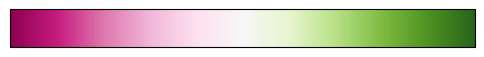

In [103]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# Define the normalization and colormap to match your script
norm = Normalize(vmin=0, vmax=25)
cmap = cm.get_cmap('PiYG')

# Create a ScalarMappable and remove the array to avoid a warning
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # Required by matplotlib for ScalarMappable

# Create a new figure for the colorbar
fig, ax = plt.subplots(figsize=(6, 1))  # wide horizontal colorbar
fig.subplots_adjust(bottom=0.5)

# Add the colorbar to the figure
cb = fig.colorbar(sm, cax=ax, orientation='horizontal')
# cb.set_label('Euclidean Distance',fontsize=20)
cb.ax.tick_params(labelsize=16)  # Increase tick label font size
ax.set_xticklabels([])
ax.set_xticks([])
# Save or show the colorbar

file_output = os.path.join(Dir_output,f'colorbar_color2.png')
plt.savefig(file_output, dpi=600, bbox_inches='tight')
plt.show()


In [ ]:
dict_palette = {'Effortless':'92 215 40', 
        'Semantic':'252 178 68',
        'Effortful':'157 102 253'
        }
df_output = df_template.copy()
df_output['fig_function'] = np.nan
for seed_idx,flag in zip([244,125,119],['Effortful','Effortless','Semantic']):
    df = dfs_output.loc[dfs_output['seed_idx']==seed_idx].copy()
    df.loc[~df['label'].isin(df['label']),'alpha'] = 0
    df.loc[(df['euclidean_sig_similar']!=True),'alpha'] = 0


    List_parcels = df.loc[df['euclidean_sig_similar']==True,'label'].values
    # print(List_parcels)
    df_output.loc[df_output['label'].isin(List_parcels),'rgb'] = dict_palette[flag]
    df_output.loc[df_output['label'].isin(List_parcels),'fig_function'] = flag

# df_output['fig_function'].unique()
df_output.loc[df_output['fig_function'].isna(),'alpha'] = 0

###
pipeline = 'framework_exploration'
rule = 'rule-distanceSig'
# file = f'Fig_{pipeline}_{rule}_color1'
# path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
# img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
# img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
# make_output_txt(df_output,path_txtOutput)

# cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
# subprocess.run(cmd, check=True)


###
pipeline = 'framework_exploration'
Dir_output = os.path.join(Dir_working,'workbench',pipeline)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)

filename = f'table_framework_{rule}.xlsx'
path_output = os.path.join(Dir_output,filename)

df_output.to_excel(path_output,index=False)

In [ ]:
pipeline = 'framework_exploration'
Dir_output = os.path.join(Dir_working,'workbench',pipeline)
# df_output.loc[df_output['fig_function'].isna(),'alpha'] = 0

rule = 'distanceSig2'
dict_palette = {'Effortless':'92 215 40', 
        'Semantic':'252 178 68',
        'Effortful':'157 102 253',
        'PO':'0 79 253'
        }

filename = f'table_framework_rule-distanceSig2.xlsx'
path_output = os.path.join(Dir_output,filename)
df_output = pd.read_excel(path_output)
for label in dict_palette:
    df_output.loc[df_output['fig_function']==label,'rgb'] = dict_palette[label]
    df_output.loc[df_output['fig_function']==label,'alpha'] = 255
df_output.loc[df_output['fig_function'].isna(),'alpha'] = 0


file = f'fig_{pipeline}_{rule}_color2'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
make_output_txt(df_output,path_txtOutput)


cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
subprocess.run(cmd, check=True)



CompletedProcess(args='Z:\\Software\\workbench\\bin_windows64\\wb_command -cifti-label-import Z:\\Software\\workbench\\atlas\\Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\framework_exploration\\fig_framework_exploration_distanceSig2_color2.txt Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\framework_exploration\\fig_framework_exploration_distanceSig2_color2.dlabel.nii', returncode=0)

In [5]:
pipeline = 'framework_exploration'
Dir_output = os.path.join(Dir_working,'workbench',pipeline)
# df_output.loc[df_output['fig_function'].isna(),'alpha'] = 0

rule = 'distanceSig_RD'
dict_palette = {'Hub':'92 215 40', 
        'Semantic':'252 178 68',
        'Lexicosemantic selection':'157 102 253',
        'PO':'0 79 253'
        }

filename = f'table_framework_rule-{rule}.xlsx'
path_output = os.path.join(Dir_output,filename)
df_output = pd.read_excel(path_output)
for label in dict_palette:
    df_output.loc[df_output['fig_function']==label,'rgb'] = dict_palette[label]
    df_output.loc[df_output['fig_function']==label,'alpha'] = 255
df_output.loc[df_output['fig_function'].isna(),'alpha'] = 0


file = f'fig_{pipeline}_{rule}_color2'
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
make_output_txt(df_output,path_txtOutput)


cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
subprocess.run(cmd, check=True)



CompletedProcess(args='Z:\\Software\\workbench\\bin_windows64\\wb_command -cifti-label-import Z:\\Software\\workbench\\atlas\\Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\framework_exploration\\fig_framework_exploration_distanceSig_RD_color2.txt Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\framework_exploration\\fig_framework_exploration_distanceSig_RD_color2.dlabel.nii', returncode=0)

In [138]:
[x for x in os.listdir(Dir_output) if '.txt' in x]

['Fig_framework_exploration_distanceSig2_color1.txt',
 'fig_framework_exploration_distanceSig2_color2.txt',
 'Fig_framework_exploration_IFG_color1.txt',
 'Fig_framework_exploration_rule-distanceSig_color1.txt',
 'Fig_framework_rule-distanceSig_color1.txt']

### ROI x ROI matrix

In [6]:
df_results = pd.read_csv(os.path.join(Dir_github,repo,'data','HCPex_p005FDR','df_ROIvalue_HCPex_p005FDR_unsmoothed.csv'))
df_results = df_results.loc[df_results['ROI_idx']!=0]
df_results = df_results.loc[~df_results['Cortical Division'].isna()]
df_results['LR'] = df_results['LR'].str.replace('idx_','')
df_results['label'] = df_results['LR']+'_'+df_results['Region']+'_ROI'
df_results['label'] = df_results['label'].str.replace(' ','')
dict_recode = {'L_7Pl_ROI':'L_7PL_ROI',
               'R_7Pl_ROI':'R_7PL_ROI'}
for old in dict_recode.keys():
    df_results.loc[df_results['label']==old,'label'] = dict_recode[old]

###
pipeline = 'distance_exploration_p005FDR_unsmoothed'

Dir_output = os.path.join(Dir_working,'workbench',pipeline)
if not os.path.exists(Dir_output):
    os.makedirs(Dir_output)
    

matrix = np.zeros((df_template.shape[0], df_template.shape[0]))
for i,rowi in df_template.iterrows():
    labeli = rowi['label']
    veci = df_results.loc[df_results['label']==labeli,'ROI_value'].values

    for j, rowj in df_template.iterrows():
        labelj = rowj['label']
        vecj = df_results.loc[df_results['label']==labelj,'ROI_value'].values
        euclidean = np.linalg.norm(veci - vecj)
        matrix[i,j] = euclidean
matrix

array([[0.        , 5.68667863, 2.46818898, ..., 7.73920254, 3.21438865,
        3.26500784],
       [5.68667863, 0.        , 6.17786154, ..., 8.87191489, 5.81948254,
        4.99859852],
       [2.46818898, 6.17786154, 0.        , ..., 7.5337807 , 3.71388015,
        2.97545477],
       ...,
       [7.73920254, 8.87191489, 7.5337807 , ..., 0.        , 6.26917927,
        6.66275198],
       [3.21438865, 5.81948254, 3.71388015, ..., 6.26917927, 0.        ,
        2.23028561],
       [3.26500784, 4.99859852, 2.97545477, ..., 6.66275198, 2.23028561,
        0.        ]])

In [7]:
from sklearn.manifold import MDS
from sklearn.metrics import euclidean_distances
import numpy as np

# D is your ROI × ROI distance matrix (e.g., 1 - correlation)
# Classical MDS with sklearn does not give variance explained directly.
# So instead, compute it manually from the eigenvalues of the double-centered matrix

# 1. Double-center the distance matrix
D = matrix
# Number of ROIs
n = D.shape[0]

# Centering matrix
H = np.eye(n) - np.ones((n, n)) / n

# Double-centered matrix
B = -0.5 * H @ (D ** 2) @ H

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(B)

# Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Select top 2 components
L = np.diag(np.sqrt(eigvals[:8]))  # diagonal matrix of sqrt of top 2 eigenvalues
V = eigvecs[:, :8]                 # top 2 eigenvectors

# ROI × 2 matrix: coordinates in 2D MDS space
X = V @ L

In [8]:
neg_ratio = np.abs(eigvals[eigvals < 0]).sum() / eigvals[eigvals > 0].sum()
print("Negative / Positive eigenvalue ratio:", neg_ratio)


Negative / Positive eigenvalue ratio: 3.611541224512737e-15


In [130]:
# keep only positive eigenvalues
pos_eigvals = eigvals[eigvals > 0]

# cumulative variance explained
cumvar = np.cumsum(pos_eigvals) / pos_eigvals.sum()

for i, v in enumerate(cumvar, start=1):
    print(i, v)


1 0.38455455666719446
2 0.5921702874606977
3 0.7427485055833807
4 0.8599328132182708
5 0.9203709073231572
6 0.9547876975078814
7 0.982697844805855
8 0.9999999999999969
9 0.9999999999999971
10 0.9999999999999972
11 0.9999999999999973
12 0.9999999999999976
13 0.9999999999999976
14 0.9999999999999976
15 0.9999999999999976
16 0.9999999999999976
17 0.9999999999999976
18 0.9999999999999976
19 0.9999999999999976
20 0.9999999999999976
21 0.9999999999999976
22 0.9999999999999976
23 0.9999999999999976
24 0.9999999999999976
25 0.9999999999999976
26 0.9999999999999976
27 0.9999999999999976
28 0.9999999999999976
29 0.9999999999999976
30 0.9999999999999976
31 0.9999999999999976
32 0.9999999999999976
33 0.9999999999999976
34 0.9999999999999976
35 0.9999999999999976
36 0.9999999999999976
37 0.9999999999999976
38 0.9999999999999976
39 0.9999999999999976
40 0.9999999999999976
41 0.9999999999999976
42 0.9999999999999976
43 0.9999999999999976
44 0.9999999999999976
45 0.9999999999999976
46 0.99999999999999

In [131]:
for i in range(360):
    print(i,eigvals[0:i].sum()/eigvals.sum())

0 0.0
1 0.38455455666719585
2 0.5921702874606998
3 0.7427485055833833
4 0.8599328132182738
5 0.9203709073231605
6 0.9547876975078847
7 0.9826978448058584
8 1.0000000000000004
9 1.0000000000000007
10 1.0000000000000007
11 1.0000000000000009
12 1.000000000000001
13 1.000000000000001
14 1.000000000000001
15 1.000000000000001
16 1.000000000000001
17 1.000000000000001
18 1.000000000000001
19 1.000000000000001
20 1.000000000000001
21 1.000000000000001
22 1.000000000000001
23 1.000000000000001
24 1.0000000000000016
25 1.0000000000000016
26 1.0000000000000016
27 1.0000000000000016
28 1.0000000000000016
29 1.0000000000000016
30 1.0000000000000016
31 1.0000000000000016
32 1.0000000000000018
33 1.0000000000000018
34 1.0000000000000018
35 1.0000000000000018
36 1.0000000000000018
37 1.0000000000000018
38 1.0000000000000018
39 1.0000000000000018
40 1.0000000000000022
41 1.0000000000000022
42 1.0000000000000022
43 1.0000000000000022
44 1.0000000000000022
45 1.0000000000000022
46 1.0000000000000022
47

In [97]:
from sklearn.manifold import MDS
from sklearn.metrics import euclidean_distances
import numpy as np
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
import numpy as np

# D is your ROI × ROI distance matrix (e.g., 1 - correlation)
# Classical MDS with sklearn does not give variance explained directly.
# So instead, compute it manually from the eigenvalues of the double-centered matrix

# 1. Double-center the distance matrix
D = matrix
# Number of ROIs
n = D.shape[0]

# Centering matrix
H = np.eye(n) - np.ones((n, n)) / n

# Double-centered matrix
B = -0.5 * H @ (D ** 2) @ H

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(B)

# Sort eigenvalues and eigenvectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Select top 2 components
L = np.diag(np.sqrt(eigvals[:8]))  # diagonal matrix of sqrt of top 2 eigenvalues
V = eigvecs[:, :8]                 # top 2 eigenvectors

# ROI × 2 matrix: coordinates in 2D MDS space
X = V @ L

### Export ###

# cutoff = 0.4
# cutoff_label = f"cutoff{cutoff:.2f}"
# cutoff_label = cutoff_label.replace('.','')
file_annot = r'D:\Software\fmri\workbench\atlas\template_annot.wb_annot'
nMDS = 8
for PC in range(1,nMDS+1):
    df_output = df_template.copy()
    df_freq = df_results.groupby(['ROI_idx','label','RegionLongName','Region','LR']).sum(numeric_only=True).reset_index()
    df_output = pd.merge(left = df_output, left_on='label',
                        right = df_freq[['label','significant_FDR']],right_on = 'label',how='left')

    norm = Normalize(vmin=np.min(X[:,PC-1]), vmax=np.max(X[:,PC-1]))

    cmap = cm.get_cmap('PiYG')  # Or 'coolwarm' for smoother gradation

    # Get RGB values
    rgb_colors = [cmap(norm(v))[:3] for v in X[:,PC-1]]  # Only RGB, drop alpha
    rgb_colors_255 = [f"{int(r*255)} {int(g*255)} {int(b*255)}" for (r, g, b) in rgb_colors]

    df_output[f'rgb'] = rgb_colors_255

    # min-max rescale to [-1,1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    column = X[:, PC-1]              # 1D
    column_2d = column.reshape(-1, 1)
    scaled_col = scaler.fit_transform(column_2d)
    df_output['MDS_distance_scaled'] = scaled_col.flatten()

    df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0
    # df_output.loc[df_output['MDS_distance_scaled'].abs()<cutoff,'alpha'] = 0

    ### ===============  =============== ###
    
    file = f'Fig_{pipeline}MDS_D{PC}_color1_masked'
    file_txt = os.path.join(Dir_output,f'{file}.txt')
    img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')


    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)

    with open(file_txt, 'w') as f:
        for i,row in df_output.iterrows():
            line = row['label']
            f.write(line + '\n')  # Add newline character explicitly

            line = f"{row['idx']} {row['rgb']} {row['alpha']}"
            f.write(line + '\n')  # Add newline character explicitly

            import subprocess

    # generate workbench image file

    cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {file_txt} {img_output}'
    # Run the command
    subprocess.run(cmd, check=True)

C:\Users\XuanR\AppData\Local\Temp\ipykernel_5644\172331325.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('PiYG')  # Or 'coolwarm' for smoother gradation
C:\Users\XuanR\AppData\Local\Temp\ipykernel_5644\172331325.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('PiYG')  # Or 'coolwarm' for smoother gradation
C:\Users\XuanR\AppData\Local\Temp\ipykernel_5644\172331325.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.g

In [73]:

def make_radarplot(df,ax,ymax):
        
    N = len(df)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

    width = 2 * np.pi / N

    # Color mapping
    color_map = {
        'pos': '#d62728',
        # 'pos_nonsig': "#c7c7c7",
        'neg': '#1f77b4',
        # 'neg_nonsig': '#c7c7c7',
    }
    # color_map_edge = {
    #     'pos_sig': '#d62728',
    #     'pos_nonsig': "#d62728",
    #     'neg_sig': '#1f77b4',
    #     'neg_nonsig': '#1f77b4',
    # }

    colors = df['color'].map(color_map)
    # colors_edge = df['color'].map(color_map_edge)

    align='edge'

    # Create plot
    # fig, ax = plt.subplots(figsize=(2, 2), subplot_kw=dict(polar=True))

    # Polar bars
    ax.bar(
        angles,
        df['value'],
        width=width,
        color=colors,
        # edgecolor=colors_edge,
        linewidth=1.2,    
        # alpha=0.8,
        align='edge'
    )

    # 🔑 rotation so 1 & 8 are centered at the top
    ax.set_theta_offset(np.pi / 2 - width / 2)
    # ax.set_theta_direction(-1)

    # Labels
    ax.set_xticks(angles + width / 2)
    ax.set_xticklabels(df['feature'])

    ax.set_ylim(0, ymax * 1.1)
    ax.set_yticklabels([])

    # ax.grid(False)
    ax.yaxis.grid(False)
    ax.spines['polar'].set_linewidth(2)
    # ax.spines['polar'].set_visible(False)
    ax.tick_params(axis='x', pad=-3,labelsize=14)
    # ax.set_title(parcel, fontsize=14, pad=25)
    # plt.tight_layout()

['L_PHA2_ROI' 'L_PHA3_ROI' 'R_TF_ROI'] ['R_STSdp_ROI' 'R_A5_ROI' 'R_A4_ROI']
['L_IFSa_ROI' 'L_PHT_ROI' 'L_PSL_ROI'] ['R_RSC_ROI' 'R_POS2_ROI' 'R_v23ab_ROI']
['R_7m_ROI' 'R_RSC_ROI' 'R_v23ab_ROI'] ['L_VIP_ROI' 'L_PH_ROI' 'L_AIP_ROI']
['L_A4_ROI' 'L_IFJa_ROI' 'L_A5_ROI'] ['R_STV_ROI' 'R_PSL_ROI' 'R_5mv_ROI']


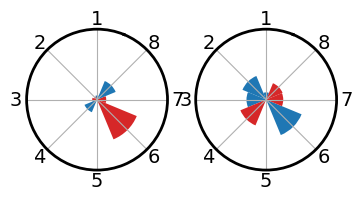

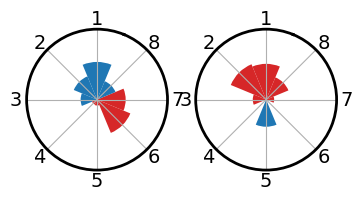

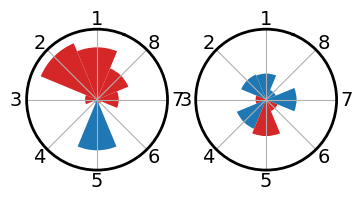

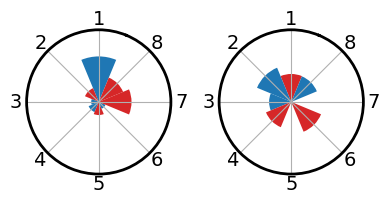

In [ ]:
df_results_wide = df_results.pivot(index=['ROI_idx','label','RegionLongName','Region','LR'], columns='iFA', values='ROI_value').reset_index()

topN = 3
for PC in range(1,4+1):
    fig, axes = plt.subplots(ncols=2,nrows=1,figsize=(4, 6), subplot_kw=dict(polar=True))
    df_output = df_template.copy()
    df_freq = df_results.groupby(['ROI_idx','label','RegionLongName','Region','LR']).sum(numeric_only=True).reset_index()
    df_output = pd.merge(left = df_output, left_on='label',
                        right = df_freq[['label','significant_FDR']],right_on = 'label',how='left')

    df_output['MDS_value'] = X[:,PC-1]

    List_parcels_min = df_output.sort_values('MDS_value',ignore_index=True,ascending=True).loc[:topN-1,'label'].values
    List_parcels_max = df_output.sort_values('MDS_value',ignore_index=True,ascending=False).loc[:topN-1,'label'].values
    print(List_parcels_min,List_parcels_max)
    for List_parcels,ax in zip([List_parcels_min,List_parcels_max],axes.flatten()):
            
        df = pd.DataFrame({'value':df_results_wide.loc[df_results_wide['label'].isin(List_parcels)].mean(numeric_only=True)[[1,2,3,4,5,6,7,8]].values})
        df['color'] = 'pos'
        df.loc[df['value']<0,'color'] = 'neg'
        df['feature'] = df.index+1
        df['value'] = df['value'].abs()
        ymax = np.max(X[:,PC-1])
        
        make_radarplot(df,ax,ymax)
plt.tight_layout()

['L_PHA2_ROI' 'L_PHA3_ROI' 'R_TF_ROI'] ['R_STSdp_ROI' 'R_A5_ROI' 'R_A4_ROI']
['L_IFSa_ROI' 'L_PHT_ROI' 'L_PSL_ROI'] ['R_RSC_ROI' 'R_POS2_ROI' 'R_v23ab_ROI']
['R_7m_ROI' 'R_RSC_ROI' 'R_v23ab_ROI'] ['L_VIP_ROI' 'L_PH_ROI' 'L_AIP_ROI']
['L_A4_ROI' 'L_IFJa_ROI' 'L_A5_ROI'] ['R_STV_ROI' 'R_PSL_ROI' 'R_5mv_ROI']


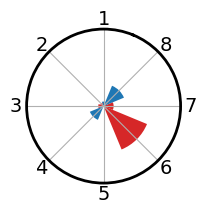

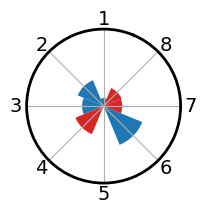

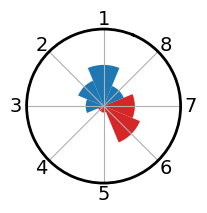

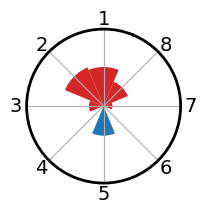

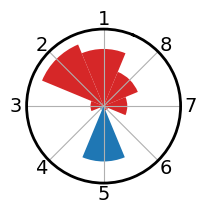

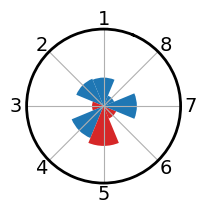

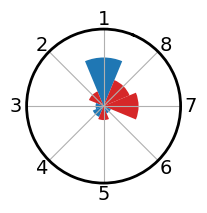

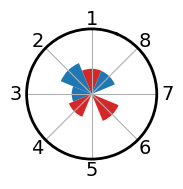

In [95]:
df_results_wide = df_results.pivot(index=['ROI_idx','label','RegionLongName','Region','LR'], columns='iFA', values='ROI_value').reset_index()

topN = 3
for PC in range(1,4+1):
    df_output = df_template.copy()
    df_freq = df_results.groupby(['ROI_idx','label','RegionLongName','Region','LR']).sum(numeric_only=True).reset_index()
    df_output = pd.merge(left = df_output, left_on='label',
                        right = df_freq[['label','significant_FDR']],right_on = 'label',how='left')

    df_output['MDS_value'] = X[:,PC-1]

    List_parcels_min = df_output.sort_values('MDS_value',ignore_index=True,ascending=True).loc[:topN-1,'label'].values
    List_parcels_max = df_output.sort_values('MDS_value',ignore_index=True,ascending=False).loc[:topN-1,'label'].values
    print(List_parcels_min,List_parcels_max)
    for label, List_parcels,ax in zip(['neg','pos'],[List_parcels_min,List_parcels_max],axes.flatten()):
        fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(2, 2), subplot_kw=dict(polar=True))
    
        df = pd.DataFrame({'value':df_results_wide.loc[df_results_wide['label'].isin(List_parcels)].mean(numeric_only=True)[[1,2,3,4,5,6,7,8]].values})
        df['color'] = 'pos'
        df.loc[df['value']<0,'color'] = 'neg'
        df['feature'] = df.index+1
        df['value'] = df['value'].abs()
        ymax = np.max(X[:,PC-1])
        
        make_radarplot(df,ax,ymax)
        fig.savefig(os.path.join(Dir_output,f'fig_radarplot_{topN}_MDS{PC}_{label}.png'),dpi=600,transparent=True,bbox_inches='tight')
plt.tight_layout()

In [93]:
label

NameError: name 'label' is not defined

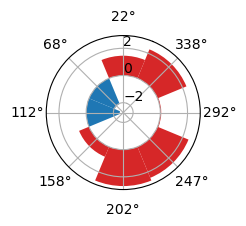

In [82]:
fig, ax = plt.subplots(ncols=1,nrows=1,figsize=(2,2), subplot_kw=dict(polar=True))
N = len(df)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

width = 2 * np.pi / N

# Color mapping
color_map = {
    'pos': '#d62728',
    # 'pos_nonsig': "#c7c7c7",
    'neg': '#1f77b4',
    # 'neg_nonsig': '#c7c7c7',
}
# color_map_edge = {
#     'pos_sig': '#d62728',
#     'pos_nonsig': "#d62728",
#     'neg_sig': '#1f77b4',
#     'neg_nonsig': '#1f77b4',
# }

colors = df['color'].map(color_map)
# colors_edge = df['color'].map(color_map_edge)

align='edge'

# Create plot
# fig, ax = plt.subplots(figsize=(2, 2), subplot_kw=dict(polar=True))

# Polar bars
ax.bar(
    angles,
    df['value'],
    width=width,
    color=colors,
    # edgecolor=colors_edge,
    linewidth=1.2,    
    # alpha=0.8,
    align='edge'
)
# ax.set_ylim(0, ymax * 1.1)
# 🔑 rotation so 1 & 8 are centered at the top
ax.set_theta_offset(np.pi / 2 - width / 2)
# ax.set_theta_direction(-1)

# Labels
ax.set_xticks(angles + width / 2)
# ax.set_xticklabels(df['feature'])


# ax.set_yticklabels([])

# # ax.grid(False)
# ax.yaxis.grid(False)
# ax.spines['polar'].set_linewidth(2)
# # ax.spines['polar'].set_visible(False)
# ax.tick_params(axis='x', pad=-3,labelsize=14)


In [159]:
df_results_wide

,,,,iFA,1,2,3,4,5,6,7,8
ROI_idx,label,RegionLongName,Region,LR,,,,,,,,
1.0,L_V1_ROI,Primary_Visual_Cortex,V1,L,-1.358210,-0.759637,-0.064355,-0.919666,1.763448,0.082089,0.011883,-0.036091
2.0,L_V2_ROI,Second_Visual_Area,V2,L,0.045815,0.054193,0.915859,-1.680439,1.689180,-0.365660,-0.303285,1.094678
3.0,L_V3_ROI,Third_Visual_Area,V3,L,0.024045,-0.218633,1.822423,-1.787948,2.743707,-2.632152,-0.941743,2.360078
4.0,L_V4_ROI,Fourth_Visual_Area,V4,L,-1.075564,-2.216242,1.039882,-1.414793,2.603602,-4.161637,-2.375973,2.142023
5.0,L_IPS1_ROI,IntraParietal_Sulcus_Area_1,IPS1,L,-1.715051,-1.309728,0.500395,-1.468688,2.542727,-2.360178,-1.733069,0.786986
...,...,...,...,...,...,...,...,...,...,...,...,...
356.0,R_a9-46v_ROI,Area_anterior_9-46v,a9-46v,R,-1.231478,-1.890877,-0.139614,-0.746515,1.675969,0.465120,-1.682894,-0.385791
357.0,R_i6-8_ROI,Inferior_6-8_Transitional_Area,i6-8,R,-0.172188,0.612909,0.672708,-1.388169,0.239656,1.723726,-0.800211,-1.991238
358.0,R_p9-46v_ROI,Area_posterior_9-46v,p9-46v,R,-1.555323,0.303437,1.314808,0.195170,0.709188,1.833495,0.705951,1.219615


# Barplot

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
df_results_wide = df_results.pivot(index=['ROI_idx','label','RegionLongName','Region','LR'], columns='iFA', values='ROI_value')

dfs_plot = []
for PC in range(1,8+1):
        
    df_output = df_template.copy()

    norm = Normalize(vmin=np.min(X[:,PC-1]), vmax=np.max(X[:,PC-1]))

    cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation

    # Get RGB values
    rgb_colors = [cmap(norm(v))[:3] for v in X[:,PC-1]]  # Only RGB, drop alpha
    rgb_colors_255 = [f"{int(r*255)} {int(g*255)} {int(b*255)}" for (r, g, b) in rgb_colors]

    df_output[f'rgb'] = rgb_colors_255

    # min-max rescale to [-1,1]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    column = X[:, PC-1]              # 1D
    column_2d = column.reshape(-1, 1)
    scaled_col = scaler.fit_transform(column_2d)
    df_output['PC_value_scaled'] = scaled_col.flatten()

    # df_output.loc[df_output['PC_value_scaled'].abs()<cutoff,'alpha'] = 0

    df_results_wide[f'PC{PC}_value_scaled'] = scaled_col.flatten()


    df_plot = pd.DataFrame(df_results_wide.corr()[f'PC{PC}_value_scaled'][0:8]).reset_index()
    df_plot['PC'] = PC
    df_plot.columns=['iFA','corr','PC']
    dfs_plot.append(df_plot)
dfs_plot = pd.concat(dfs_plot,ignore_index=True)


C:\Users\XuanR\AppData\Local\Temp\ipykernel_41312\3407175225.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation
C:\Users\XuanR\AppData\Local\Temp\ipykernel_41312\3407175225.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation
C:\Users\XuanR\AppData\Local\Temp\ipykernel_41312\3407175225.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.

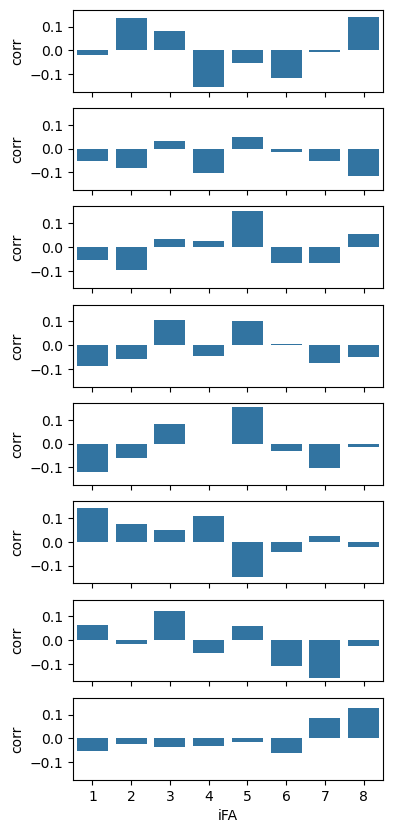

In [96]:
fig,axes = plt.subplots(ncols=1,nrows=8,figsize=(4,10),sharex=True,sharey=True)
for PC, ax in zip(range(1,8+1),axes.flatten()):
    df_plot = dfs_plot.loc[dfs_plot['PC']==PC]
    sns.barplot(df_plot,x='iFA',y='corr',ax=ax)